# Metro Network w. OD analysis

In [ ]:
import pandas as pd
import numpy as np
import geopandas as gpd

import matplotlib.pyplot as plt
import matplotlib as mpl
import networkx as nx
import seaborn as sns
from itertools import tee, pairwise, combinations

In [3]:
from scripts.network_scripts import station_flow_metrics, compute_temporal_mixing

In [67]:
k5_palette = [
    "#265EF8",
    "#DE3EC4",
    "#F16F32", 
    "#37BB53",
    '#19180A'
]

In [4]:
m1m2_stations = ['Flintholm', 'Lindevang', 'Fasanvej', 'Christianshavn', 'Sundby',
       'Bella Center', 'Femøren', 'Kastrup', 'Københavns Lufthavn',
       'Nørreport', 'Vanløse', 'Forum',
       'Islands Brygge', 'DR Byen', 'Ørestad', 'Vestamager', 'Amagerbro',
       'Lergravsparken', 'Øresund', 'Amager Strand'
]

m3m4_stations = ['Gammel Strand', 'Trianglen', 'Nuuks Plads',
       'Frederiksberg Allé', 'Enghave Plads', 'Havneholmen',
       'Enghave Brygge', 'Sluseholmen', 'København H',
       'Rådhuspladsen', 'Marmorkirken', 'Østerport',
       'Poul Henningsens Plads', 'Vibenshus Runddel', 'Skjolds Plads',
       'Nørrebro', 'Nørrebros Runddel', 'Aksel Møllers Have', 'Orientkaj',
       'Nordhavn', 'Mozarts Plads', 'København Syd']

m1m2_m3m4_stations = ['Kongens Nytorv', 'Frederiksberg']

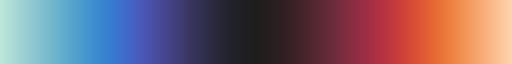

In [5]:
sns.color_palette("icefire", as_cmap=True)


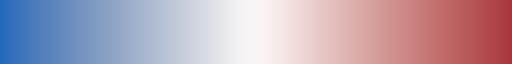

In [6]:
sns.color_palette("vlag", as_cmap=True)


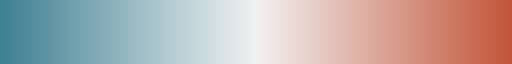

In [7]:
sns.diverging_palette(220, 20, as_cmap=True)


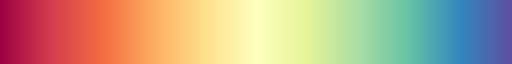

In [8]:
sns.color_palette("Spectral", as_cmap=True)


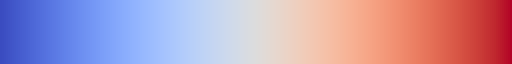

In [9]:
sns.color_palette("coolwarm", as_cmap=True)


## Loading Files

### Infrastructure & Metro Features

In [10]:
municipalities = gpd.read_file("../data/OSM/copenhagen_metric.gpkg", layer="metro municipalities")
mun_area = gpd.read_file("../data/OSM/copenhagen_metric.gpkg", layer="greater metro area")

In [11]:
# STEP 1: Reading in metro stations and lines
metro_stations = gpd.read_file("../data/OSM/copenhagen_metric.gpkg", layer="metro stations")
metro_lines = gpd.read_file("../data/OSM/copenhagen_metric.gpkg", layer="metro lines")

# Ensure both are in a projected CRS (meters)
gdf_stations = metro_stations.to_crs(epsg=25832)
gdf_stations.reset_index(drop=False, inplace=True)

gdf_tracks = metro_lines.to_crs(epsg=25832)
gdf_tracks.reset_index(drop=False, inplace=True)

In [12]:
metro_lines.head()

,id,name,colour,geometry
0,4054540,Metro M1,#007756,"LINESTRING (725145.774 6169544.808, 725182.064..."
1,4245710,Metro M1+M2,#ffcc00,"LINESTRING (721586.084 6176246.957, 721629.988..."
2,4317977,Metro M1,#007756,"LINESTRING (725479.85 6174367.246, 725492.24 6..."
3,10075451,Metro M1+M2,#ffcc00,"LINESTRING (722047.184 6176249.923, 722051.908..."
4,10075453,Metro M1+M2,#ffcc00,"LINESTRING (723347.635 6176377.496, 723373.813..."


### Neighborhood Attributes

In [13]:
# SOCIO-DEMOGRAPHIC
social = pd.read_csv("../data/otm/processed/station_otm_norm_socio.csv")
social = social.drop(columns=['id', 'system'])
print("Social attributes:", social.shape[1]-1)

# FUNCTIONAL
functional = pd.read_csv("../data/processed/station_functional.csv")
functional = functional.drop(columns=['id', 'system'])
print("Functional attributes:", functional.shape[1]-1)

# ENVIRONMENT
env = pd.read_csv("../data/processed/station_landcomposition_basic.csv")
env = env.drop(columns=['id', 'system'])
print("Environment attributes:", env.shape[1]-1)

# ALL COMBINED
all = pd.read_csv("../data/processed/station_characteristics.csv")
all = all.drop(columns=['id', 'system'])
print("All Neighborhood Attributes:", all.shape[1]-1)

Social attributes: 20
Functional attributes: 35
Environment attributes: 7
All Neighborhood Attributes: 69


In [14]:
all.head()

,name,B_COMSERV,B_INDU,B_PUBINST,B_RES,B_TOTAL,GREEN,WATER,U_REC,U_PROD,...,OSKIL_S,OUSKIL_S,ORET_S,OSTU_S,ONOP_S,HOUSEH1,HOUSEH2,HOUSEH3,CARS,CDEN
0,Lindevang,4.237660,0.107864,4.285484,16.043073,26.474333,4.511777,0.003261,0.800019,5.746303,...,9.609895,17.861777,20.915146,12.516218,3.779950,46.0,30.0,24.0,3112.0,230.946197
1,Københavns Lufthavn,11.729353,0.325271,13.721635,3.190858,29.638224,4.920478,1.092997,1.566558,12.563812,...,7.794508,24.889283,26.040744,9.654562,8.060230,35.0,33.0,32.0,498.0,378.132118
2,Vestamager,2.920754,0.000000,0.773784,12.859545,18.242509,25.903574,9.755156,0.268388,0.638599,...,10.185417,17.815084,10.987221,14.507642,4.247056,42.0,30.0,28.0,1997.0,213.560047
3,Ørestad,10.156321,0.000000,1.933568,5.070250,18.411940,27.016369,3.900953,1.310685,24.630666,...,9.789580,19.387870,9.913357,14.403061,4.185890,44.0,29.0,27.0,2210.0,205.926202
4,Femøren,1.821096,0.500817,0.809897,8.566972,13.404511,42.811881,4.233764,0.000000,4.259218,...,8.378871,25.318761,23.169399,9.362477,6.885246,42.0,31.0,27.0,1080.0,330.578512


### Neighborhood Clusters

In [15]:
# FINAL
neigh_types = pd.read_csv("../results/clustering/neighborhood/multi_method_labels.csv")

### Station pairs & Distance

In [16]:
station_pairs = pd.read_excel("../data/Metroselskabet/station_pairs_distance.xlsx", sheet_name="Sheet2")
station_labels = pd.read_excel("../data/Metroselskabet/stopPoint2Name.xlsx")
station_list = station_labels["stationName"].unique().tolist()

# Create mapping dictionary from abbreviations to full names
mapping = dict(zip(station_labels["stopName"], station_labels["stationName"]))

# Map onto df_edges
station_pairs["Fra_full"] = station_pairs["Fra"].map(mapping)
station_pairs["Til_full"] = station_pairs["Til"].map(mapping)
station_pairs.head()

,Fra,Til,Akk. afstand (km),Afstand (meter),Fra_full,Til_full
0,VAN,FL,0.45,450,Vanløse,Flintholm
1,FL,LIT,1.36,910,Flintholm,Lindevang
2,LIT,SOT,2.04,680,Lindevang,Fasanvej
3,SOT,FB,2.56,520,Fasanvej,Frederiksberg
4,FB,FOR,3.93,1370,Frederiksberg,Forum


### OD Flows

In [17]:
# reading in OD values
od_total = pd.read_csv("../data/Metroselskabet/OD/total/OD_total.csv")
#df_od_cluster = assign cluster value for each station...
#od_cluster_gb = df_od_cluster.groupby(['from_cluster', 'to_cluster']).sum()

print(od_total.shape)
od_total.head()

(1892, 3)


,from,to,trips
0,Aksel Møllers Have,Amager Strand,1841.0
1,Aksel Møllers Have,Amagerbro,19376.0
2,Aksel Møllers Have,Bella Center,11478.0
3,Aksel Møllers Have,Christianshavn,17700.0
4,Aksel Møllers Have,DR Byen,13262.0


In [18]:
od_morning = pd.read_csv("../data/Metroselskabet/OD/mean/OD_morning_peak.csv")
od_noon = pd.read_csv("../data/Metroselskabet/OD/mean/OD_midday.csv")
od_afternoon = pd.read_csv("../data/Metroselskabet/OD/mean/OD_afternoon_peak.csv")
od_evening = pd.read_csv("../data/Metroselskabet/OD/mean/OD_evening.csv")
od_night = pd.read_csv("../data/Metroselskabet/OD/mean/OD_night.csv")

print(od_morning.shape)
od_morning.head()

print(od_afternoon.shape)
od_afternoon.head()

(1892, 3)
(1892, 3)


,from,to,afternoon_peak_trips
0,Aksel Møllers Have,Amager Strand,17.0
1,Aksel Møllers Have,Amagerbro,213.0
2,Aksel Møllers Have,Bella Center,94.0
3,Aksel Møllers Have,Christianshavn,152.0
4,Aksel Møllers Have,DR Byen,61.0


In [19]:
od_all = od_total.merge(od_morning, on=['from', 'to'],
                   how='left')
od_all = od_all.merge(od_noon, on=['from', 'to'],
                   how='left')
od_all = od_all.merge(od_afternoon, on=['from', 'to'],
                   how='left')
od_all = od_all.merge(od_evening, on=['from', 'to'],
                   how='left')
od_all = od_all.merge(od_night, on=['from', 'to'],
                   how='left')
od_all = od_all.rename(columns={"morning_peak_trips": "morning_trips",
                                "midday_trips": "noon_trips",
                                "afternoon_peak_trips": "afternoon_trips"})
od_all.head()

,from,to,trips,morning_trips,noon_trips,afternoon_trips,evening_trips,night_trips
0,Aksel Møllers Have,Amager Strand,1841.0,5.0,32.0,17.0,20.0,2.0
1,Aksel Møllers Have,Amagerbro,19376.0,41.0,269.0,213.0,252.0,32.0
2,Aksel Møllers Have,Bella Center,11478.0,141.0,156.0,94.0,74.0,13.0
3,Aksel Møllers Have,Christianshavn,17700.0,165.0,268.0,152.0,129.0,23.0
4,Aksel Møllers Have,DR Byen,13262.0,194.0,205.0,61.0,80.0,13.0


In [20]:
od_all.columns

Index(['from', 'to', 'trips', 'morning_trips', 'noon_trips', 'afternoon_trips',
       'evening_trips', 'night_trips'],
      dtype='object')

# Graph Construction

### Base Graph (Distance weighted)

In [21]:
# Base graph, edges weighted by distance
BG = nx.Graph()
for index, row in station_pairs.iterrows():
    u = row["Fra_full"]
    v = row["Til_full"]
    d = row["Afstand (meter)"]
    #t = row['Travel time (seconds)']
    #print(u, v, d)
    BG.add_edge(u, v, distance=d) # travel_time=t

# TO DO: Add node attributes from gdf_stations    

print("Undirected topology graph built.")
print("Nodes:", BG.number_of_nodes())
print("Edges:", BG.number_of_edges())

Undirected topology graph built.
Nodes: 44
Edges: 45


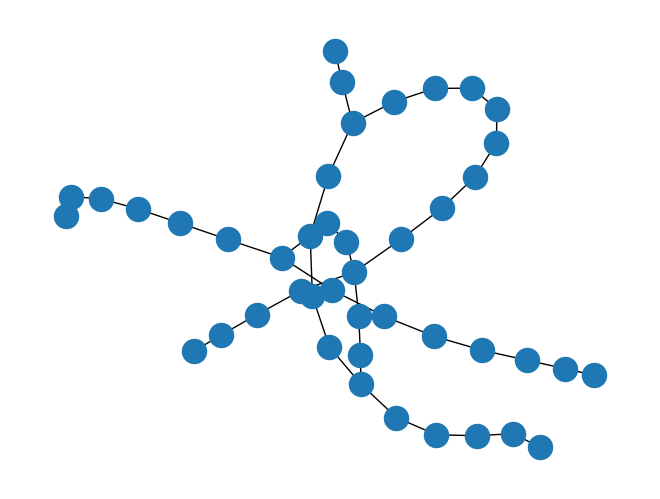

In [22]:
nx.draw(BG)

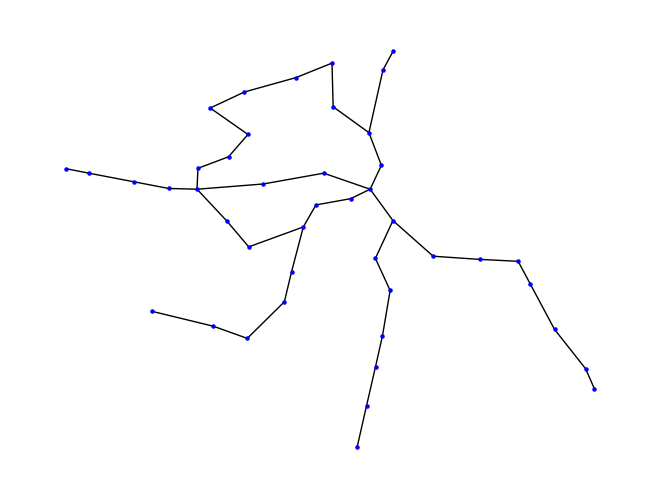

In [23]:
# Get station coordinates
gdf_stations_indexed = gdf_stations.set_index("name")
nodes = list(BG.nodes())
gdf_ordered = gdf_stations_indexed.reindex(nodes)

station_coordinates = np.column_stack((
    gdf_ordered.geometry.x.values,
    gdf_ordered.geometry.y.values
))

# To plot with networkx, we need to merge the nodes back to
# their positions in order to plot in networkx
positions = dict(zip(BG.nodes, station_coordinates))

#f, ax = plt.subplots(1, 2, figsize=(8, 4))
nx.draw(BG, positions, node_size=5, node_color="blue")
plt.show()

In [24]:
# TO DO: Save graph as gpkg?
#https://networkx.org/documentation/latest/auto_examples/geospatial/plot_osmnx.html

### Directed and Flow Weighted Grap

In [25]:
DG = nx.DiGraph()

def pairwise(iterable):
    a, b = tee(iterable)
    next(b, None)
    return zip(a, b)

# Add edges in both directions (From base graph)
for u, v, data in BG.edges(data=True):
    dist = data["distance"]
    DG.add_edge(u, v, distance=dist, 
                flow=0.0,
                flow_morning=0.0,
                flow_noon=0.0,
                flow_afternoon=0.0,
                flow_evening=0.0,
                flow_night=0.0
                )
    DG.add_edge(v, u, distance=dist, 
                flow=0.0,
                flow_morning=0.0,
                flow_noon=0.0,
                flow_afternoon=0.0,
                flow_evening=0.0,
                flow_night=0.0
                )

print("\nDirected graph created for OD flow assignment.")
print("Directed edges:", DG.number_of_edges())


Directed graph created for OD flow assignment.
Directed edges: 90


In [ ]:
# ASSIGN OD FLOWS TO SHORTEST PATHS

missing_paths = 0

for _, row in od_all.iterrows():
    O = row['from']        # adjust column names as needed
    D = row['to']
    F = row['trips']          # hourly average passengers
    F_morning = row['morning_trips']
    F_noon = row['noon_trips']
    F_afternoon = row['afternoon_trips']
    F_evening = row['evening_trips']
    F_night = row['night_trips']

    # Skip cases where O == D
    if O == D:
        continue

    try:
        # Compute shortest path by distance
        path = nx.shortest_path(DG, O, D, weight="distance")

        # Assign flow to each directed edge in the path
        for u, v in pairwise(path):
            DG[u][v]["flow"] += F
            DG[u][v]["flow_morning"] += F_morning
            DG[u][v]["flow_noon"] += F_noon
            DG[u][v]["flow_afternoon"] += F_afternoon
            DG[u][v]["flow_evening"] += F_evening
            DG[u][v]["flow_night"] += F_night
            

    except nx.NetworkXNoPath:
        missing_paths += 1
        continue

for u, v, d in DG.edges(data=True):
    d["inv_flow"] = 1 / d["flow"] # inverted flow

print("\nOD Flow assignment completed.")
print("Missing OD paths:", missing_paths)


OD Flow assignment completed.
Missing OD paths: 0


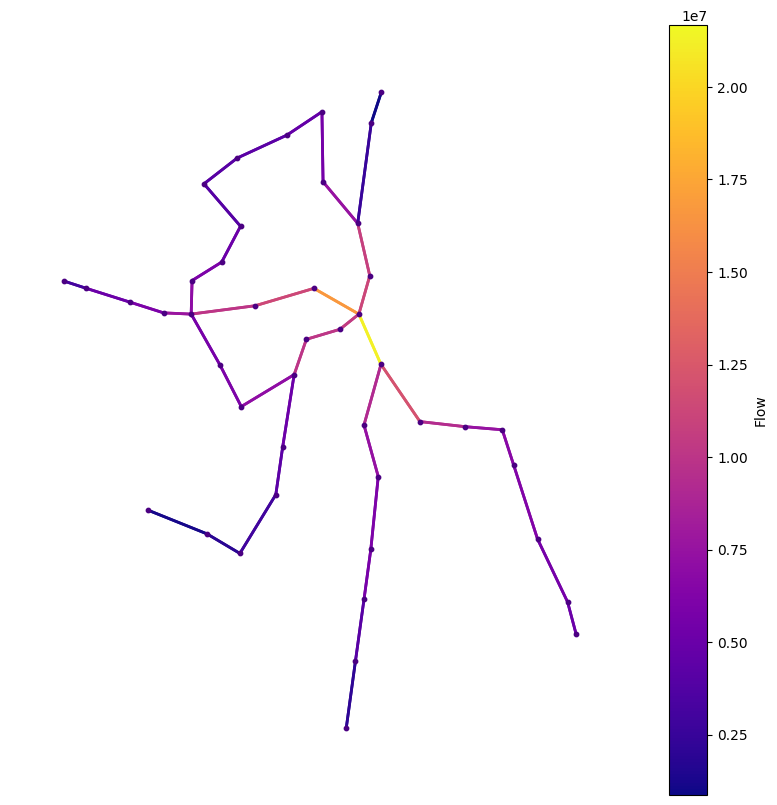

In [27]:
# --- Extract flow values for all edges ---
flows = np.array([data["flow"] for _, _, data in DG.edges(data=True)])

# Avoid vmin=vmax (happens if all flows are zero)
vmin = flows.min()
vmax = flows.max() if flows.max() > flows.min() else flows.min() + 1e-6

cmap = plt.cm.plasma
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_axis_off()

# Plot nodes
nx.draw_networkx_nodes(
    DG, positions,
    node_size=10, node_color="indigo",
    ax=ax)

# Plot edges with colormap based on flow
edge_coll = nx.draw_networkx_edges(
    DG, positions,
    edge_color=flows,         # <-- IMPORTANT
    edge_cmap=cmap,
    edge_vmin=vmin, edge_vmax=vmax,
    width=2, arrows=False,             # optional, arrows make LineCollection tricky
    ax=ax)

# Add colorbar
cbar = plt.colorbar(edge_coll, ax=ax)
cbar.set_label("Flow", rotation=90)
plt.show()

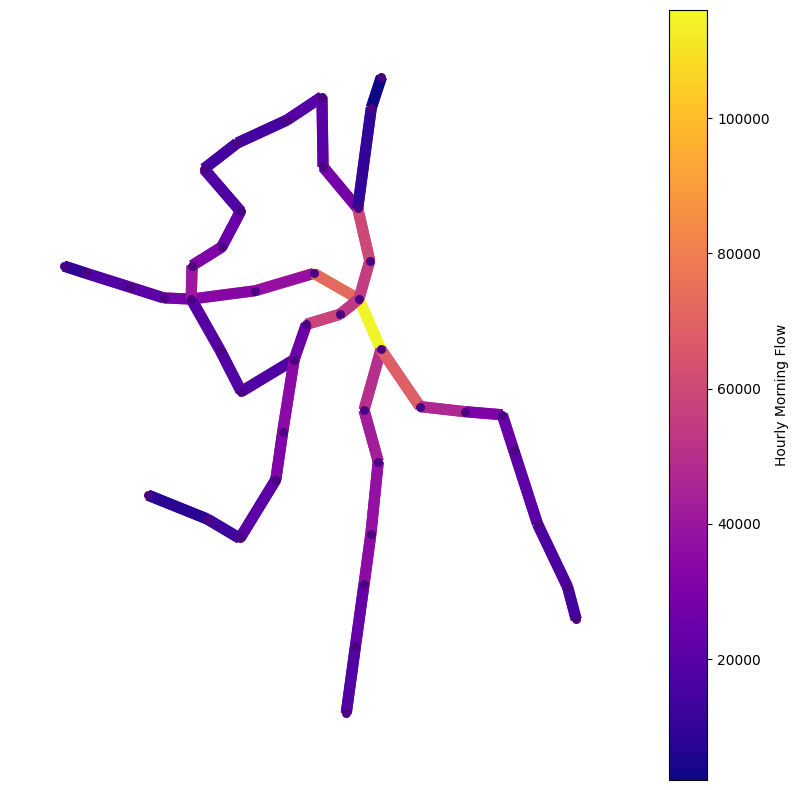

In [28]:
flows = np.array([data["flow_morning"] for _, _, data in DG.edges(data=True)])

# Avoid vmin=vmax (happens if all flows are zero)
vmin = flows.min()
vmax = flows.max() if flows.max() > flows.min() else flows.min() + 1e-6

cmap = plt.cm.plasma
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_axis_off()

# Plot nodes
nx.draw_networkx_nodes(
    DG, positions,
    node_size=30, node_color="indigo",
    ax=ax)

# Plot edges with colormap based on flow
edge_coll = nx.draw_networkx_edges(
    DG, positions,
    edge_color=flows,         # <-- IMPORTANT
    edge_cmap=cmap,
    edge_vmin=vmin, edge_vmax=vmax,
    width=8, arrows=False,             # optional, arrows make LineCollection tricky
    ax=ax)

# Add colorbar
cbar = plt.colorbar(edge_coll, ax=ax)
cbar.set_label("Hourly Morning Flow", rotation=90)
plt.show()

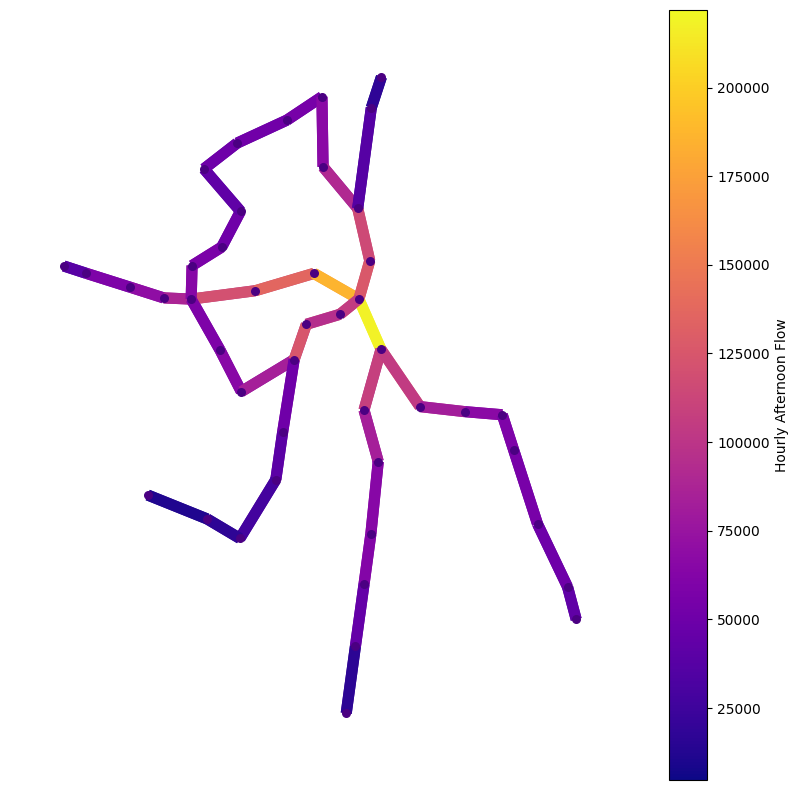

In [29]:
# --- Extract flow values for all edges ---
flows = np.array([data["flow_afternoon"] for _, _, data in DG.edges(data=True)])

# Avoid vmin=vmax (happens if all flows are zero)
vmin = flows.min()
vmax = flows.max() if flows.max() > flows.min() else flows.min() + 1e-6

cmap = plt.cm.plasma
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_axis_off()

# Plot nodes
nx.draw_networkx_nodes(
    DG, positions,
    node_size=30, node_color="indigo",
    ax=ax)

# Plot edges with colormap based on flow
edge_coll = nx.draw_networkx_edges(
    DG, positions,
    edge_color=flows,         # <-- IMPORTANT
    edge_cmap=cmap,
    edge_vmin=vmin, edge_vmax=vmax,
    width=8, arrows=False,             # optional, arrows make LineCollection tricky
    ax=ax)

# Add colorbar
cbar = plt.colorbar(edge_coll, ax=ax)
cbar.set_label("Hourly Afternoon Flow", rotation=90)
plt.show()

# Distances

In [ ]:
# Precompute all-pairs shortest path lengths
# Result: dict-of-dicts: dist[u][v]
all_distances = dict(nx.all_pairs_dijkstra_path_length(BG, weight="distance"))

In [31]:
def compute_within_cluster_distance(stations_df, cluster_col, dist_dict):
    """
    stations_df : DataFrame with columns ['name', cluster_col]
    cluster_col : str, e.g. 'k_5'
    dist_dict   : output of all_pairs_dijkstra_path_length
    
    Returns
    -------
    DataFrame with per-cluster distance statistics
    """

    results = []

    for cluster_id, group in stations_df.groupby(cluster_col):
        stations = group["name"].tolist()

        # Skip trivial clusters
        if len(stations) < 2:
            continue

        dists = []
        for i, j in combinations(stations, 2):
            if i in dist_dict and j in dist_dict[i]:
                dists.append(dist_dict[i][j])

        results.append({
            "cluster": cluster_id,
            "n_stations": len(stations),
            "mean_within_dist": np.mean(dists),
            "median_within_dist": np.median(dists),
            "min_within_dist": np.min(dists),
            "max_within_dist": np.max(dists)
        })

    return pd.DataFrame(results)


In [32]:
within_dist_df = compute_within_cluster_distance(
    stations_df=neigh_types,
    cluster_col="k_5",
    dist_dict=all_distances
)

within_dist_df


,cluster,n_stations,mean_within_dist,median_within_dist,min_within_dist,max_within_dist
0,1,6,1520.000000,1400.0,500,3040
1,2,10,4340.666667,5260.0,520,7830
2,3,9,6521.666667,7760.0,700,11700
3,4,9,6492.222222,6950.0,500,11720
4,5,10,9062.666667,10660.0,450,15350


# Flow Metrics

In [ ]:
def station_flow_metrics(DiG,
                         BaG, 
                         od_df, 
                         trips_cols=['trips', 'morning_trips', 'noon_trips', 'afternoon_trips', 'evening_trips', 'night_trips'], 
                         #flow_col=["flow", "flow_morning", "flow_noon", "flow_afternoon", "flow_evening", "flow_night"],
                         temporal_norm=False, 
                         station_names=None):
    metrics_df = pd.DataFrame()

    for trip_col in trips_cols:
        if trip_col =="trips":
            flow_col = "flow"
        else:
            time_split = trip_col.split("_")[0]
            flow_col = "flow_" + time_split
        print(trip_col, flow_col)

        # 1. start and end nodes
        origins = od_df.groupby("from")[trip_col].sum().reindex(DG.nodes(), fill_value=0)
        destinations = od_df.groupby("to")[trip_col].sum().reindex(DG.nodes(), fill_value=0)
        metrics_df[f'{trip_col}_origins'] = origins
        metrics_df[f'{trip_col}_destinations'] = destinations

        # 2. node inflow and outflow
        inflow = DiG.in_degree(weight=flow_col)     # People arriving at or through station
        outflow = DiG.out_degree(weight=flow_col)   # People departing at or through station
        inflow_values = {node: inflow[node] for node in DiG.nodes()}
        outflow_values = {node: outflow[node] for node in DiG.nodes()}
        metrics_df[f'{trip_col}_inflow'] = inflow_values
        metrics_df[f'{trip_col}_outflow'] = outflow_values

        # 3. node through-flow
        node_flow = {node: 0 for node in DiG.nodes()}
        for u, v, data in DiG.edges(data=True):
            node_flow[u] += data[flow_col]
            node_flow[v] += data[flow_col]
        metrics_df[f'{trip_col}_node_flow'] = node_flow

        # 3. Transfer Flow
        through_flow = {}
        for n in DiG.nodes():
            through_flow[n] = inflow[n] + outflow[n] - origins[n] - destinations[n]
        metrics_df[f'{trip_col}_through_flow'] = through_flow


    # 4. structural centralities
    closeness = nx.closeness_centrality(BaG, distance="distance")
    betweenness = nx.betweenness_centrality(BaG, weight="distance")
    metrics_df['closeness'] = closeness
    metrics_df['betweenness'] = betweenness

    if temporal_norm:
        EPS = 1e-6

        # identify base (daily) columns
        base_outflow = metrics_df["trips_outflow"]
        base_node_flow = metrics_df["trips_node_flow"]

        for trip_col in trips_cols:
            if trip_col == "trips":
                continue  # skip base, used for normalization

            inflow = metrics_df[f"{trip_col}_inflow"]
            outflow = metrics_df[f"{trip_col}_outflow"]
            node_flow = metrics_df[f"{trip_col}_node_flow"]
            through_flow = metrics_df[f"{trip_col}_through_flow"]

            # --- Directional imbalance ---
            metrics_df[f"{trip_col}_net_flow"] = outflow - inflow
            metrics_df[f"{trip_col}_net_flow_norm"] = (
                metrics_df[f"{trip_col}_net_flow"] / (node_flow + EPS)
            )

            metrics_df[f"{trip_col}_out_in_ratio"] = (
                outflow / (inflow + EPS)
            )

            # --- Temporal share (within-station normalization) ---
            metrics_df[f"{trip_col}_outflow_share"] = (
                outflow / (base_outflow + EPS)
            )

            metrics_df[f"{trip_col}_node_flow_share"] = (
                node_flow / (base_node_flow + EPS)
            )

            # --- Transfer intensity ---
            metrics_df[f"{trip_col}_through_flow_share"] = (
                through_flow / (node_flow + EPS)
            )



    metrics_df = metrics_df.reset_index(names=['station'])
    return metrics_df

In [34]:
all_flow_metrics = station_flow_metrics(DG, BG, od_all)
all_flow_metrics.head()

trips flow
morning_trips flow_morning
noon_trips flow_noon
afternoon_trips flow_afternoon
evening_trips flow_evening
night_trips flow_night


,station,trips_origins,trips_destinations,trips_inflow,trips_outflow,trips_node_flow,trips_through_flow,morning_trips_origins,morning_trips_destinations,morning_trips_inflow,...,evening_trips_node_flow,evening_trips_through_flow,night_trips_origins,night_trips_destinations,night_trips_inflow,night_trips_outflow,night_trips_node_flow,night_trips_through_flow,closeness,betweenness
0,Vanløse,3588740.0,3137623.0,3137623.0,3588740.0,6726363.0,0.0,26054.0,9205.0,9205.0,...,59404.0,0.0,8768.0,10366.0,10366.0,8768.0,19134.0,0.0,0.000128,0.000000
1,Flintholm,2270188.0,2105347.0,8657434.0,8822275.0,17479709.0,13104174.0,15479.0,9714.0,44149.0,...,155360.0,115984.0,5154.0,6840.0,25728.0,24042.0,49770.0,37776.0,0.000135,0.046512
2,Lindevang,1194477.0,1101500.0,11637934.0,11730911.0,23368845.0,21072868.0,8418.0,4012.0,61369.0,...,208648.0,189196.0,2938.0,3189.0,33319.0,33068.0,66387.0,60260.0,0.000153,0.090808
3,Fasanvej,2079548.0,2183945.0,14310155.0,14205758.0,28515913.0,24252420.0,12931.0,10436.0,75723.0,...,255391.0,218578.0,5640.0,6441.0,41166.0,40365.0,81531.0,69450.0,0.000168,0.132890
4,Frederiksberg,4459291.0,4854548.0,30994669.0,30599412.0,61594081.0,52280242.0,17262.0,17210.0,151037.0,...,587799.0,505084.0,10441.0,9902.0,91609.0,92148.0,183757.0,163414.0,0.000182,0.303433


In [35]:
all_flow_metrics2 = station_flow_metrics(DG, BG, od_all, temporal_norm=True)
all_flow_metrics2.head()

trips flow
morning_trips flow_morning
noon_trips flow_noon
afternoon_trips flow_afternoon
evening_trips flow_evening
night_trips flow_night


,station,trips_origins,trips_destinations,trips_inflow,trips_outflow,trips_node_flow,trips_through_flow,morning_trips_origins,morning_trips_destinations,morning_trips_inflow,...,evening_trips_out_in_ratio,evening_trips_outflow_share,evening_trips_node_flow_share,evening_trips_through_flow_share,night_trips_net_flow,night_trips_net_flow_norm,night_trips_out_in_ratio,night_trips_outflow_share,night_trips_node_flow_share,night_trips_through_flow_share
0,Vanløse,3588740.0,3137623.0,3137623.0,3588740.0,6726363.0,0.0,26054.0,9205.0,9205.0,...,0.673918,0.006664,0.008832,0.000000,-1598.0,-0.083516,0.845842,0.002443,0.002845,0.000000
1,Flintholm,2270188.0,2105347.0,8657434.0,8822275.0,17479709.0,13104174.0,15479.0,9714.0,44149.0,...,0.908951,0.008385,0.008888,0.746550,-1686.0,-0.033876,0.934468,0.002725,0.002847,0.759011
2,Lindevang,1194477.0,1101500.0,11637934.0,11730911.0,23368845.0,21072868.0,8418.0,4012.0,61369.0,...,0.964208,0.008731,0.008928,0.906771,-251.0,-0.003781,0.992467,0.002819,0.002841,0.907708
3,Fasanvej,2079548.0,2183945.0,14310155.0,14205758.0,28515913.0,24252420.0,12931.0,10436.0,75723.0,...,0.939880,0.008710,0.008956,0.855856,-801.0,-0.009824,0.980542,0.002841,0.002859,0.851823
4,Frederiksberg,4459291.0,4854548.0,30994669.0,30599412.0,61594081.0,52280242.0,17262.0,17210.0,151037.0,...,1.008930,0.009647,0.009543,0.859280,539.0,0.002933,1.005884,0.003011,0.002983,0.889294


In [36]:
normalization_map = {
    "morning_trips_inflow": "trips_inflow",
    "morning_trips_outflow": "trips_outflow",
    "morning_trips_node_flow": "trips_node_flow",
    "morning_trips_through_flow": "trips_through_flow",

    "evening_trips_inflow": "trips_inflow",
    "evening_trips_outflow": "trips_outflow",
    "evening_trips_node_flow": "trips_node_flow",
    "evening_trips_through_flow": "trips_through_flow",

    "night_trips_inflow": "trips_inflow",
    "night_trips_outflow": "trips_outflow",
    "night_trips_node_flow": "trips_node_flow",
    "night_trips_through_flow": "trips_through_flow",
}


df_rel = all_flow_metrics.copy()

for num_col, denom_col in normalization_map.items():
    df_rel[num_col + "_share"] = (
        df_rel[num_col] / df_rel[denom_col]
    )

df_rel.replace([float("inf"), -float("inf")], pd.NA, inplace=True)

df_rel[
    ["morning_trips_inflow_share",
     "evening_trips_inflow_share",
     "night_trips_inflow_share"]
].sum(axis=1).describe()



count    44.000000
mean      0.018003
std       0.001266
min       0.016624
25%       0.017365
50%       0.017755
75%       0.018099
max       0.025143
dtype: float64

In [37]:
df_rel[[
    "station",
    "trips_inflow",
    "morning_trips_inflow",
    "morning_trips_inflow_share"
]]


,station,trips_inflow,morning_trips_inflow,morning_trips_inflow_share
0,Vanløse,3137623.0,9205.0,0.002934
1,Flintholm,8657434.0,44149.0,0.005100
2,Lindevang,11637934.0,61369.0,0.005273
3,Fasanvej,14310155.0,75723.0,0.005292
4,Frederiksberg,30994669.0,151037.0,0.004873
5,Forum,22001302.0,111261.0,0.005057
6,Frederiksberg Allé,11758981.0,47303.0,0.004023
7,Aksel Møllers Have,12626058.0,52128.0,0.004129
8,Nørreport,28630450.0,155351.0,0.005426
9,Kongens Nytorv,60267838.0,333313.0,0.005531


#### Neighborhood correlation

In [38]:
flow_neighatt = all_flow_metrics.merge(all,
                                       left_on='station',
                                       right_on='name',
                                       how='left')


In [39]:
flow_cols = [i for i in all_flow_metrics.columns[1:]]
flow_cols

['trips_origins',
 'trips_destinations',
 'trips_inflow',
 'trips_outflow',
 'trips_node_flow',
 'trips_through_flow',
 'morning_trips_origins',
 'morning_trips_destinations',
 'morning_trips_inflow',
 'morning_trips_outflow',
 'morning_trips_node_flow',
 'morning_trips_through_flow',
 'noon_trips_origins',
 'noon_trips_destinations',
 'noon_trips_inflow',
 'noon_trips_outflow',
 'noon_trips_node_flow',
 'noon_trips_through_flow',
 'afternoon_trips_origins',
 'afternoon_trips_destinations',
 'afternoon_trips_inflow',
 'afternoon_trips_outflow',
 'afternoon_trips_node_flow',
 'afternoon_trips_through_flow',
 'evening_trips_origins',
 'evening_trips_destinations',
 'evening_trips_inflow',
 'evening_trips_outflow',
 'evening_trips_node_flow',
 'evening_trips_through_flow',
 'night_trips_origins',
 'night_trips_destinations',
 'night_trips_inflow',
 'night_trips_outflow',
 'night_trips_node_flow',
 'night_trips_through_flow',
 'closeness',
 'betweenness']

In [40]:
flow_corr_cols = ['trips_origins', 'trips_destinations',
                  'trips_inflow', 'trips_outflow',
                  'trips_node_flow', 'trips_through_flow',
                  'closeness', 'betweenness']
neigh_att_cols = ['POP', 'POP15_S', 'HOUSEH1', 'HOUSEH3', 
                  'JOBS', 'JOBS_POP15', 'STU_POP',
                  'CARS', 'CDEN', 'INCLOW_S', 'INCHIGH_S',
                  'B_TOTAL', 'B_RES', 'GREEN', 'POI_TOTAL'
]

corr = flow_neighatt[flow_corr_cols + neigh_att_cols].corr()
corr_flow_neigh = corr.loc[flow_corr_cols, neigh_att_cols]
corr_flow_neigh

,POP,POP15_S,HOUSEH1,HOUSEH3,JOBS,JOBS_POP15,STU_POP,CARS,CDEN,INCLOW_S,INCHIGH_S,B_TOTAL,B_RES,GREEN,POI_TOTAL
trips_origins,0.032467,0.364618,-0.151348,-0.090566,0.587174,0.497252,0.298141,0.024556,-0.039577,-0.059234,0.098183,0.578439,-0.036096,-0.154864,0.624376
trips_destinations,0.018081,0.369408,-0.172968,-0.077168,0.595490,0.512546,0.302419,0.014539,-0.018602,-0.071879,0.109447,0.578500,-0.056698,-0.154339,0.618077
trips_inflow,0.060119,0.511184,-0.025939,-0.327015,0.596329,0.388296,0.214578,0.113993,-0.035101,-0.287899,0.279931,0.447925,0.059310,-0.122791,0.562365
trips_outflow,0.063229,0.512250,-0.021008,-0.331781,0.596057,0.385490,0.213701,0.116742,-0.039250,-0.287442,0.279442,0.448095,0.064045,-0.122966,0.564443
trips_node_flow,0.061669,0.511727,-0.023484,-0.329396,0.596209,0.386908,0.214147,0.115365,-0.037168,-0.287679,0.279695,0.448021,0.061669,-0.122881,0.563414
trips_through_flow,0.063777,0.495192,0.008552,-0.351541,0.541739,0.325496,0.175685,0.125242,-0.035480,-0.308630,0.291450,0.378267,0.079196,-0.104623,0.498544
closeness,0.230560,0.638930,0.174731,-0.507094,0.725299,0.461726,0.412311,0.239070,-0.310148,-0.350248,0.443014,0.622908,0.180736,-0.247783,0.742098
betweenness,0.038875,0.529008,0.046745,-0.352084,0.593098,0.380319,0.207710,0.079144,-0.150251,-0.352075,0.382223,0.413566,-0.019541,-0.150461,0.492495


In [41]:
corr_flow_neigh = (
    flow_neighatt[flow_corr_cols + neigh_att_cols]
    .corr(method="spearman")
    .loc[flow_corr_cols, neigh_att_cols]
)

corr_flow_neigh

,POP,POP15_S,HOUSEH1,HOUSEH3,JOBS,JOBS_POP15,STU_POP,CARS,CDEN,INCLOW_S,INCHIGH_S,B_TOTAL,B_RES,GREEN,POI_TOTAL
trips_origins,0.222692,0.364764,-0.133416,-0.179868,0.585765,0.308386,0.190070,0.259056,-0.041156,0.021564,0.057928,0.630867,0.129105,-0.166455,0.629145
trips_destinations,0.235236,0.377731,-0.154857,-0.173465,0.619450,0.346300,0.199584,0.265962,-0.038055,0.021424,0.058210,0.626638,0.115152,-0.143622,0.625410
trips_inflow,0.144891,0.417759,-0.044472,-0.489633,0.461311,0.188724,0.373304,0.189429,0.069063,-0.337562,0.278083,0.416631,0.157999,-0.029598,0.567965
trips_outflow,0.145314,0.412544,-0.040718,-0.489781,0.453418,0.175617,0.374855,0.191121,0.067371,-0.337703,0.273714,0.416913,0.163214,-0.037350,0.568740
trips_node_flow,0.150106,0.410994,-0.040501,-0.489633,0.461311,0.183510,0.373304,0.194785,0.063848,-0.336152,0.276533,0.419450,0.164482,-0.037209,0.570855
trips_through_flow,0.110296,0.415656,-0.045153,-0.493293,0.400423,0.162059,0.354455,0.153456,0.079972,-0.365868,0.294640,0.347814,0.137941,-0.016502,0.491342
closeness,0.311769,0.557717,-0.024402,-0.481832,0.652995,0.260888,0.403961,0.299225,-0.176180,-0.368428,0.451445,0.577449,0.205779,-0.247075,0.683630
betweenness,0.105598,0.460605,-0.062664,-0.403937,0.454743,0.250539,0.318995,0.079322,-0.111814,-0.448244,0.394633,0.359316,0.013420,-0.103055,0.431015


In [42]:
strong = (
    corr_flow_neigh
    .abs()
    .stack()
    .sort_values(ascending=False)
)

strong[strong > 0.5]


closeness           POI_TOTAL    0.683630
                    JOBS         0.652995
trips_origins       B_TOTAL      0.630867
                    POI_TOTAL    0.629145
trips_destinations  B_TOTAL      0.626638
                    POI_TOTAL    0.625410
                    JOBS         0.619450
trips_origins       JOBS         0.585765
closeness           B_TOTAL      0.577449
trips_node_flow     POI_TOTAL    0.570855
trips_outflow       POI_TOTAL    0.568740
trips_inflow        POI_TOTAL    0.567965
closeness           POP15_S      0.557717
dtype: float64

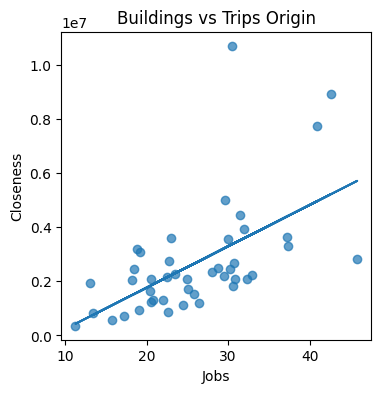

In [43]:
x = flow_neighatt["B_TOTAL"]
y = flow_neighatt["trips_origins"]

plt.figure(figsize=(4,4))
plt.scatter(x, y, alpha=0.7)
plt.xlabel("Jobs")
plt.ylabel("Closeness")
plt.title("Buildings vs Trips Origin")

# optional trend line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.show()

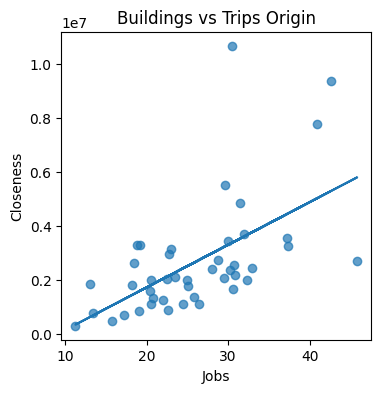

In [44]:
x = flow_neighatt["B_TOTAL"]
y = flow_neighatt["trips_destinations"]

plt.figure(figsize=(4,4))
plt.scatter(x, y, alpha=0.7)
plt.xlabel("Jobs")
plt.ylabel("Closeness")
plt.title("Buildings vs Trips Origin")

# optional trend line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.show()

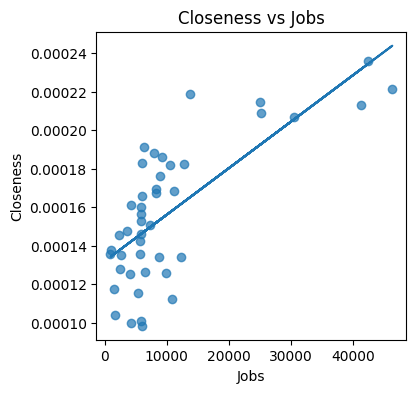

In [45]:
x = flow_neighatt["JOBS"]
y = flow_neighatt["closeness"]

plt.figure(figsize=(4,4))
plt.scatter(x, y, alpha=0.7)
plt.xlabel("Jobs")
plt.ylabel("Closeness")
plt.title("Closeness vs Jobs")

# optional trend line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.show()


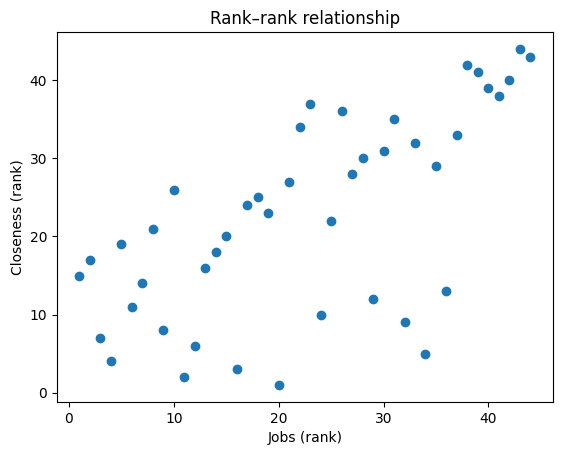

In [46]:
plt.scatter(x.rank(), y.rank())
plt.xlabel("Jobs (rank)")
plt.ylabel("Closeness (rank)")
plt.title("Rank–rank relationship")
plt.show()


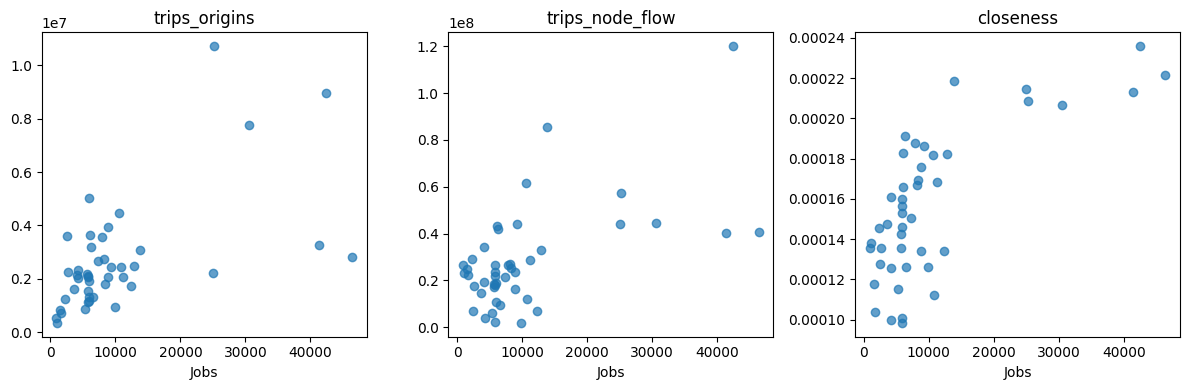

In [47]:
metrics = ["trips_origins", "trips_node_flow", "closeness"]

fig, axes = plt.subplots(1, len(metrics), figsize=(12,4))

for ax, m in zip(axes, metrics):
    ax.scatter(flow_neighatt["JOBS"], flow_neighatt[m], alpha=0.7)
    ax.set_title(m)
    ax.set_xlabel("Jobs")

plt.tight_layout()
plt.show()


# OD Analysis

## Observed OD Mixing
P_obs tells something about::
- Diagonal dominance → spatial / functional self-containment
- Strong off-diagonal entries → inter-cluster coupling
- Asymmetry → hierarchy (e.g., residential → work ≠ work → residential)
- Low row entropy → specialized origin clusters
- High row entropy → diversified mobility patterns

In [49]:
# Function to compute mixing for a single time slice
def compute_temporal_mixing(od, trip_col):
    """
    od: dataframe with columns cluster_from, cluster_to, trip_col
    trip_col: str, e.g. 'morning_trips'
    """

    df = (
        od
        .groupby(["cluster_from", "cluster_to"], as_index=False)[trip_col]
        .sum()
        .rename(columns={trip_col: "trips"})
    )

    df["total_out"] = df.groupby("cluster_from")["trips"].transform("sum")
    df["P_obs"] = (df["trips"] / df["total_out"]) * 100

    P = df.pivot(
        index="cluster_from",
        columns="cluster_to",
        values="P_obs"
    ).fillna(0)

    # absolute volume
    F_obs = (
        df
        .pivot(index="cluster_from", columns="cluster_to", values="trips")
        .fillna(0)
    )

    return P

In [ ]:
od_focus = od_all[["from", "to", "morning_trips", "afternoon_trips"]].copy()

chosen_k = 'k_5' # CLUSTER RESOLUTION
stations_df = neigh_types.copy()
stations_df = stations_df[['name', chosen_k]]

od_focus = od_focus.merge(
    stations_df.rename(columns={"name": "from", chosen_k: "cluster_from"}),
    on="from",
    how="left"
    )

od_focus = od_focus.merge(
    stations_df.rename(columns={"name": "to", chosen_k: "cluster_to"}),
    on="to",
    how="left"
    )
od_focus.head()

,from,to,morning_trips,afternoon_trips,cluster_from,cluster_to
0,Aksel Møllers Have,Amager Strand,5.0,17.0,2,5
1,Aksel Møllers Have,Amagerbro,41.0,213.0,2,3
2,Aksel Møllers Have,Bella Center,141.0,94.0,2,4
3,Aksel Møllers Have,Christianshavn,165.0,152.0,2,4
4,Aksel Møllers Have,DR Byen,194.0,61.0,2,3


In [51]:
# total trips departing clusters
od_fromcluster_gb = od_focus.groupby(['cluster_from'])[['morning_trips', 'afternoon_trips']].sum()
od_fromcluster_gb

# total trips arriving clusters
od_tocluster_gb = od_focus.groupby(['cluster_to'])[['morning_trips', 'afternoon_trips']].sum()
od_tocluster_gb

,morning_trips,afternoon_trips
cluster_to,,
1,200610.0,355858.0
2,107401.0,271458.0
3,71717.0,249349.0
4,112127.0,194254.0
5,72381.0,177680.0


#### Cluster-level (heatmaps/matrices)

In [52]:
P_morning = compute_temporal_mixing(od_focus, "morning_trips")
P_afternoon = compute_temporal_mixing(od_focus, "afternoon_trips")

# enforce cluster order
clusters = sorted(stations_df[chosen_k].unique())
P_morning = P_morning.reindex(index=clusters, columns=clusters, fill_value=0)
P_afternoon = P_afternoon.reindex(index=clusters, columns=clusters, fill_value=0)

P_temporal = P_afternoon - P_morning

In [53]:
P_morning

cluster_to,1,2,3,4,5
cluster_from,,,,,
1,17.749362,22.000629,16.495617,25.329154,18.425238
2,37.770792,16.396553,13.814868,18.500994,13.516793
3,40.526021,20.601188,12.565986,16.753213,9.553592
4,43.309430,16.417376,10.274425,20.567868,9.430902
5,38.111236,19.214020,9.771155,19.402571,13.501019


In [54]:
P_afternoon

cluster_to,1,2,3,4,5
cluster_from,,,,,
1,15.546395,24.386148,24.189202,19.521953,16.356302
2,33.474100,18.565069,21.339944,13.057507,13.563381
3,36.275123,23.024518,17.572962,12.436932,10.690465
4,36.081220,18.844053,16.366555,15.299355,13.408818
5,34.712137,21.965688,14.692815,13.372265,15.257095


/var/folders/4n/hkfy_b_x7nb3cp347mdrfysr0000gn/T/ipykernel_58840/2840039123.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


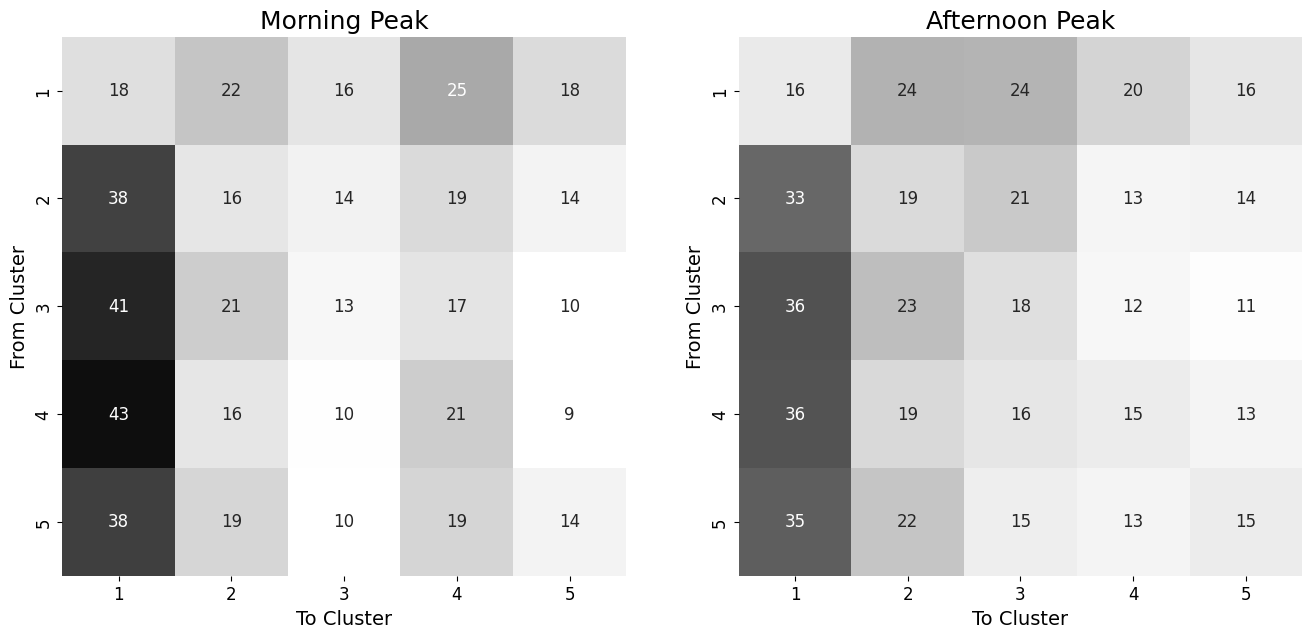

In [58]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(16, 7),
                               gridspec_kw={"wspace": 0.2}
                               )
ax1 = sns.heatmap(P_morning, cmap='Greys', ax=ax1, annot=True, fmt=".0f",
                  vmin=10, vmax=45, cbar=False,
                  annot_kws={"size": 12})
ax2 = sns.heatmap(P_afternoon, cmap='Greys', ax=ax2, annot=True, fmt=".0f",
                  vmin=10, vmax=45, cbar=False,
                  annot_kws={"size": 12})

#ax1.set(xlabel="To Cluster", ylabel="From Cluster")
#ax2.set(xlabel="To Cluster", ylabel="From Cluster")

ax1.set_title('Morning Peak', fontsize=18)
ax2.set_title('Afternoon Peak', fontsize=18)

for ax in (ax1, ax2):
    ax.set_xlabel("To Cluster", fontsize=14)
    ax.set_ylabel("From Cluster", fontsize=14)
    ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.savefig("../results/plots/od/od_heatmap.png")
plt.show()

/var/folders/4n/hkfy_b_x7nb3cp347mdrfysr0000gn/T/ipykernel_58840/1464679191.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


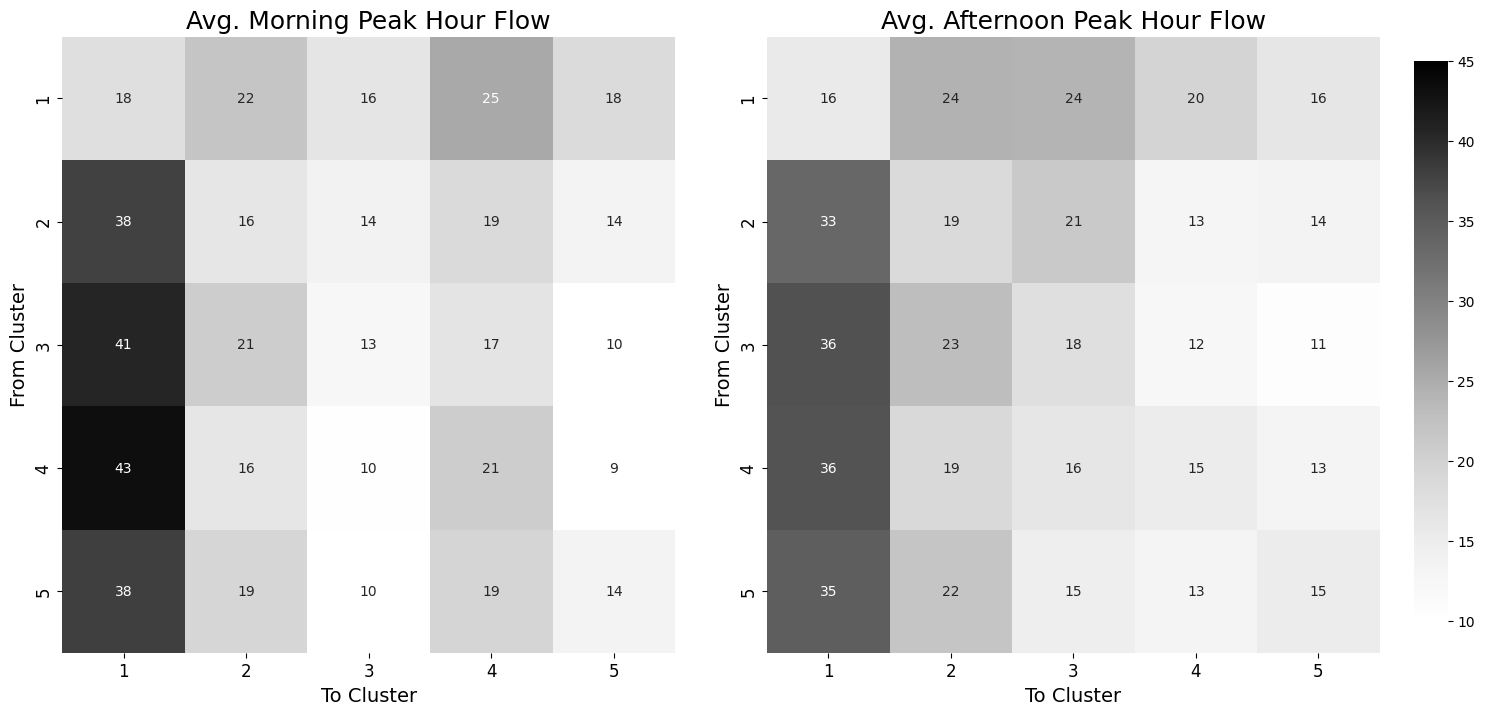

In [59]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(17, 8),
    gridspec_kw={"wspace": 0.15}
)

# Create an axis for the shared colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
# [left, bottom, width, height] in figure coordinates

sns.heatmap(
    P_morning,
    cmap='Greys',
    ax=ax1, annot=True, fmt=".0f",
    vmin=10, vmax=45, cbar=True, cbar_ax=cbar_ax
)

sns.heatmap(
    P_afternoon,
    cmap='Greys',
    ax=ax2, annot=True, fmt=".0f",
    vmin=10, vmax=45, cbar=False
)

ax1.set_title("Avg. Morning Peak Hour Flow", fontsize=18)
ax2.set_title("Avg. Afternoon Peak Hour Flow", fontsize=18)

for ax in (ax1, ax2):
    ax.set_xlabel("To Cluster", fontsize=14)
    ax.set_ylabel("From Cluster", fontsize=14)
    ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.savefig("../results/plots/od/od_heatmap_v2.png")
plt.show()

/var/folders/4n/hkfy_b_x7nb3cp347mdrfysr0000gn/T/ipykernel_58840/1965855972.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


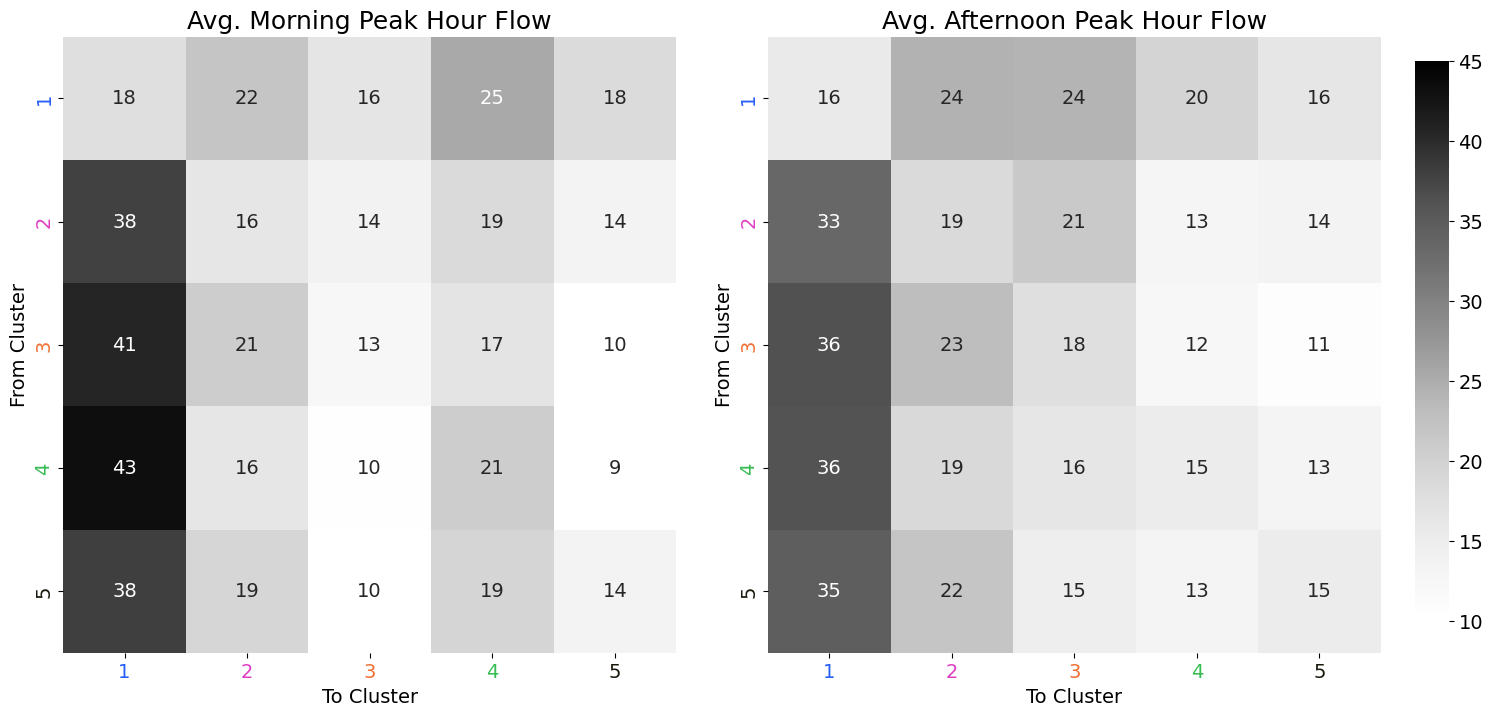

In [73]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(17, 8),
    gridspec_kw={"wspace": 0.15}
)

# Create an axis for the shared colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
# [left, bottom, width, height] in figure coordinates

sns.heatmap(
    P_morning,
    cmap='Greys',
    ax=ax1,
    annot=True,
    fmt=".0f",
    annot_kws={"size": 14},   # 👈 increase this
    vmin=10, vmax=45,
    cbar=True, cbar_ax=cbar_ax
)

sns.heatmap(
    P_afternoon,
    cmap='Greys',
    ax=ax2, annot=True, fmt=".0f",
    annot_kws={"size": 14},   # 👈 increase this
    vmin=10, vmax=45, cbar=False
)

ax1.set_title("Avg. Morning Peak Hour Flow", fontsize=18)
ax2.set_title("Avg. Afternoon Peak Hour Flow", fontsize=18)

for ax in (ax1, ax2):
    ax.set_xlabel("To Cluster", fontsize=14)
    ax.set_ylabel("From Cluster", fontsize=14)

    for tick, color in zip(ax.get_xticklabels(), k5_palette):
        tick.set_color(color)
        tick.set_fontsize(14)

    for tick, color in zip(ax.get_yticklabels(), k5_palette):
        tick.set_color(color)
        tick.set_fontsize(14)
    
cbar_ax.tick_params(labelsize=14)  # increase this value

plt.tight_layout()
plt.savefig("../results/plots/od/od_heatmap_v2.png")
plt.show()

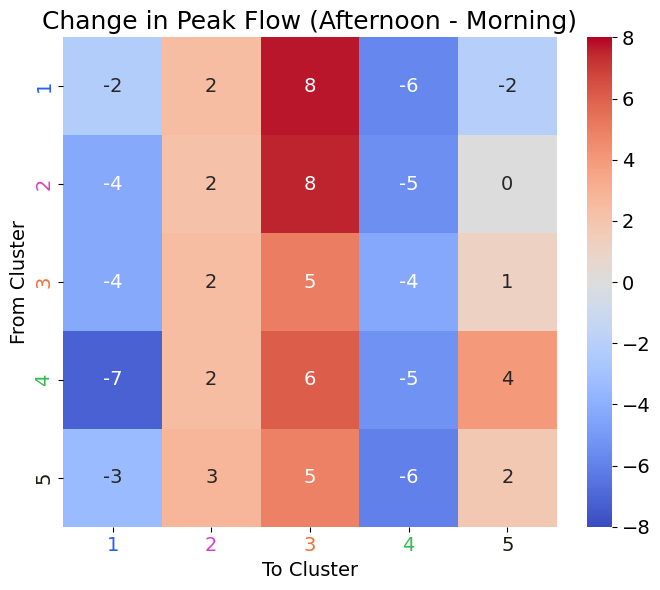

In [74]:
fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(
    P_temporal,
    cmap='coolwarm',
    center=0,
    vmin=-8, vmax=8,   # scale to your actual probabilities
    ax=ax,
    annot=True, fmt=".0f",
    annot_kws={"size": 14}
)

#ax.set(
#    xlabel="To Cluster",
#    ylabel="From Cluster",
#    title="Change in OD mixing probabilities (Afternoon − Morning)"
#)

ax.set_title("Change in Peak Flow (Afternoon - Morning)", fontsize=18)

ax.set_xlabel("To Cluster", fontsize=14)
ax.set_ylabel("From Cluster", fontsize=14)
ax.tick_params(axis='both', labelsize=14)
ax.collections[0].colorbar.ax.tick_params(labelsize=14)

for tick, color in zip(ax.get_yticklabels(), k5_palette):
    tick.set_color(color)
    tick.set_fontsize(14)

for tick, color in zip(ax.get_xticklabels(), k5_palette):
    tick.set_color(color)
    tick.set_fontsize(14)

plt.tight_layout()
plt.savefig("../results/plots/od/od_heatmap_norm.png")
plt.show()

In [ ]:
within_dist_df["P_morning_cc"] = within_dist_df["cluster"].map(
    lambda c: P_morning.loc[c, c]
)

within_dist_df["P_afternoon_cc"] = within_dist_df["cluster"].map(
    lambda c: P_afternoon.loc[c, c]
)

# OD Flow Network Metrics

Make a DataFrame like:<br>
station	inflow	outflow	through_flow	closeness	betweenness	cluster

This lets you see:
- some stations are structurally central but not heavily used
- others are heavily used but not central (crowded suburbs)

In [ ]:
def station_flow_metrics(DiG,
                         BaG, 
                         od_df, 
                         trips_cols=['trips', 'morning_trips', 'noon_trips', 'afternoon_trips', 'evening_trips', 'night_trips'], 
                         #flow_col=["flow", "flow_morning", "flow_noon", "flow_afternoon", "flow_evening", "flow_night"],
                         station_names=None):
    metrics_df = pd.DataFrame()

    for trip_col in trips_cols:
        if trip_col =="trips":
            flow_col = "flow"
        else:
            time_split = trip_col.split("_")[0]
            flow_col = "flow_" + time_split
        print(trip_col, flow_col)

        # 1. start and end nodes
        origins = od_df.groupby("from")[trip_col].sum().reindex(DG.nodes(), fill_value=0)
        destinations = od_df.groupby("to")[trip_col].sum().reindex(DG.nodes(), fill_value=0)
        metrics_df[f'{trip_col}_origins'] = origins
        metrics_df[f'{trip_col}_destinations'] = destinations

        # 2. node inflow and outflow
        inflow = DiG.in_degree(weight=flow_col)     # People arriving at or through station
        outflow = DiG.out_degree(weight=flow_col)   # People departing at or through station
        inflow_values = {node: inflow[node] for node in DiG.nodes()}
        outflow_values = {node: outflow[node] for node in DiG.nodes()}
        metrics_df[f'{trip_col}_inflow'] = inflow_values
        metrics_df[f'{trip_col}_outflow'] = outflow_values

        # 3. node through-flow
        node_flow = {node: 0 for node in DiG.nodes()}
        for u, v, data in DiG.edges(data=True):
            node_flow[u] += data[flow_col]
            node_flow[v] += data[flow_col]
        metrics_df[f'{trip_col}_node_flow'] = node_flow

        # 3. transfer flow
        through_flow = {}
        for n in DiG.nodes():
            through_flow[n] = inflow[n] + outflow[n] - origins[n] - destinations[n]
        metrics_df[f'{trip_col}_through_flow'] = through_flow


    # 4. structural centralities
    closeness = nx.closeness_centrality(BaG, distance="distance")
    betweenness = nx.betweenness_centrality(BaG, weight="distance")
    metrics_df['closeness'] = closeness
    metrics_df['betweenness'] = betweenness

    metrics_df = metrics_df.reset_index(names=['station'])
    return metrics_df

In [98]:
station_flow_metrics = station_flow_metrics(DG, BG, od_all)
station_flow_metrics.head()

trips flow
morning_trips flow_morning
noon_trips flow_noon
afternoon_trips flow_afternoon
evening_trips flow_evening
night_trips flow_night


,station,trips_origins,trips_destinations,trips_inflow,trips_outflow,trips_node_flow,trips_through_flow,morning_trips_origins,morning_trips_destinations,morning_trips_inflow,...,evening_trips_node_flow,evening_trips_through_flow,night_trips_origins,night_trips_destinations,night_trips_inflow,night_trips_outflow,night_trips_node_flow,night_trips_through_flow,closeness,betweenness
0,Vanløse,3588740.0,3137623.0,3137623.0,3588740.0,6726363.0,0.0,26054.0,9205.0,9205.0,...,59404.0,0.0,8768.0,10366.0,10366.0,8768.0,19134.0,0.0,0.000128,0.000000
1,Flintholm,2270188.0,2105347.0,8657434.0,8822275.0,17479709.0,13104174.0,15479.0,9714.0,44149.0,...,155360.0,115984.0,5154.0,6840.0,25728.0,24042.0,49770.0,37776.0,0.000135,0.046512
2,Lindevang,1194477.0,1101500.0,11637934.0,11730911.0,23368845.0,21072868.0,8418.0,4012.0,61369.0,...,208648.0,189196.0,2938.0,3189.0,33319.0,33068.0,66387.0,60260.0,0.000153,0.090808
3,Fasanvej,2079548.0,2183945.0,14310155.0,14205758.0,28515913.0,24252420.0,12931.0,10436.0,75723.0,...,255391.0,218578.0,5640.0,6441.0,41166.0,40365.0,81531.0,69450.0,0.000168,0.132890
4,Frederiksberg,4459291.0,4854548.0,30994669.0,30599412.0,61594081.0,52280242.0,17262.0,17210.0,151037.0,...,587799.0,505084.0,10441.0,9902.0,91609.0,92148.0,183757.0,163414.0,0.000182,0.303433


In [ ]:
# normalize at station level
station_flow_metrics['closeness_norm'] = station_flow_metrics['closeness'] / all_flow_metrics['closeness'].mean()
station_flow_metrics['betweenness_norm'] = station_flow_metrics['betweenness'] / all_flow_metrics['betweenness'].mean()

In [107]:
station_flow_metrics_w_types_all = station_flow_metrics.merge(neigh_types,
                                           left_on='station', right_on='name',
                                           how='left')
station_flow_metrics_w_types_all.head()
station_flow_metrics_w_types_all.to_csv("../results_flow_metrics_all.csv", index=False)

In [ ]:
cluster_col = "k_5" # CLUSTER RESOLUTION
df = station_flow_metrics_w_types_all.rename(columns={cluster_col: "cluster"}).copy()

In [ ]:
# station temporal shares from node_flow per time period
periods = ["morning", "noon", "afternoon", "evening", "night"]
node_flow_cols = {p: f"{p}_trips_node_flow" for p in periods}

# Safety check: make sure expected columns exist
missing = [c for c in node_flow_cols.values() if c not in df.columns]
if missing:
    raise ValueError(
        "Missing expected node-flow columns:\n"
        + "\n".join(missing)
        + "\n\nCheck your CSV column names (e.g., 'noon' vs 'midday')."
    )

# total station activity
df["total_activity"] = df[list(node_flow_cols.values())].sum(axis=1)

# station-level shares
for p, col in node_flow_cols.items():
    df[f"share_{p}"] = np.where(df["total_activity"] > 0, df[col] / df["total_activity"], 0.0)

In [ ]:
# station-level highlight off-peak tendencies

# peak share = morning + afternoon
df["peak_share"] = df["share_morning"] + df["share_afternoon"]
df["offpeak_share"] = 1.0 - df["peak_share"]  # noon + evening + night

# inflow_asymmetry: 1 = morning sink, -1 = afternoon sink, 0 = balanced
if {"morning_trips_inflow", "afternoon_trips_inflow"}.issubset(df.columns):
    den = df["morning_trips_inflow"] + df["afternoon_trips_inflow"]
    df["inflow_asymmetry"] = np.where(
        den > 0,
        (df["morning_trips_inflow"] - df["afternoon_trips_inflow"]) / den,
        0.0
    )
else:
    df["inflow_asymmetry"] = np.nan  # if those columns don’t exist in your file

In [ ]:
# cluster-level aggregation: mean + spread, IQR
def iqr(x):
    x = pd.to_numeric(x, errors="coerce")
    return np.nanpercentile(x, 75) - np.nanpercentile(x, 25)

cluster_summary = (
    df.groupby("cluster")
      .agg(
          n_stations=("station", "count") if "station" in df.columns else ("cluster", "size"),
          peak_share_mean=("peak_share", "mean"),
          peak_share_iqr=("peak_share", iqr),
          offpeak_share_mean=("offpeak_share", "mean"),
          offpeak_share_iqr=("offpeak_share", iqr),
          inflow_asym_mean=("inflow_asymmetry", "mean"),
          inflow_asym_iqr=("inflow_asymmetry", iqr),
      )
      .reset_index()
      .sort_values("cluster")
)

print("\nCluster summary (temporal profile indicators):")
print(cluster_summary)


Cluster summary (temporal profile indicators):
   cluster  n_stations  peak_share_mean  peak_share_iqr  offpeak_share_mean  \
0        1           6         0.373436        0.013515            0.626564   
1        2          10         0.375766        0.013447            0.624234   
2        3           9         0.362518        0.027335            0.637482   
3        4           9         0.410671        0.023949            0.589329   
4        5          10         0.346928        0.079198            0.653072   

   offpeak_share_iqr  inflow_asym_mean  inflow_asym_iqr  
0           0.013515         -0.343743         0.071279  
1           0.013447         -0.358665         0.030816  
2           0.027335         -0.396690         0.096642  
3           0.023949         -0.224419         0.142358  
4           0.079198         -0.392239         0.184608  


In [ ]:
# identify "atypical" stations within each cluster (salience within-cluster)
# station is atypical if (|z| > 1).

threshold = 1
indicators = ["offpeak_share", "inflow_asymmetry"]

atyp = df.loc[:, [c for c in ["station", "cluster"] + indicators if c in df.columns]].copy()

for ind in indicators:
    if ind not in atyp.columns:
        continue
    mu = atyp.groupby("cluster")[ind].transform("mean")
    sd = atyp.groupby("cluster")[ind].transform("std").replace(0, np.nan)
    atyp[f"z_{ind}_within_cluster"] = (atyp[ind] - mu) / sd
    atyp[f"atypical_{ind}"] = atyp[f"z_{ind}_within_cluster"].abs() > threshold

# Count atypical stations per cluster
atyp_counts = (
    atyp.groupby("cluster")
        .agg(
            atypical_offpeak=("atypical_offpeak_share", "sum") if "atypical_offpeak_share" in atyp.columns else ("cluster", "size"),
            atypical_asym=("atypical_inflow_asymmetry", "sum") if "atypical_inflow_asymmetry" in atyp.columns else ("cluster", "size"),
        )
        .reset_index()
)

# If some atypical columns weren't created, fix counts gracefully
if "atypical_offpeak_share" not in atyp.columns:
    atyp_counts["atypical_offpeak"] = np.nan
if "atypical_inflow_asymmetry" not in atyp.columns:
    atyp_counts["atypical_asym"] = np.nan

cluster_summary = cluster_summary.merge(
    atyp_counts[["cluster", "atypical_offpeak", "atypical_asym"]],
    on="cluster",
    how="left"
)

print("\nCluster summary + atypical counts:")
print(cluster_summary)

In [ ]:
# most off-peak-oriented stations
if "station" in df.columns:
    top_offpeak = (
        df.sort_values("offpeak_share", ascending=False)
          .loc[:, [c for c in ["station", "cluster", "offpeak_share", "inflow_asymmetry", "trips_node_flow"] if c in df.columns]]
          .head(10)
    )
    print("Top 10 off-peak-oriented stations:")
    print(top_offpeak)


Top 10 off-peak-oriented stations:
                station  cluster  offpeak_share  inflow_asymmetry  \
25  Københavns Lufthavn        5       0.707349         -0.096812   
24              Kastrup        5       0.702238         -0.268103   
23              Femøren        5       0.694034         -0.301672   
22        Amager Strand        5       0.688301         -0.313578   
21              Øresund        5       0.681493         -0.319343   
20       Lergravsparken        3       0.669822         -0.344526   
14            Amagerbro        3       0.657920         -0.370592   
6    Frederiksberg Allé        2       0.652956         -0.441586   
26        Enghave Plads        3       0.649698         -0.477008   
28          Nuuks Plads        3       0.647532         -0.428168   

    trips_node_flow  
25       10549314.0  
24       22347220.0  
23       24809964.0  
22       26745737.0  
21       28981629.0  
20       34280399.0  
14       43369723.0  
6        23568952.0  
26    

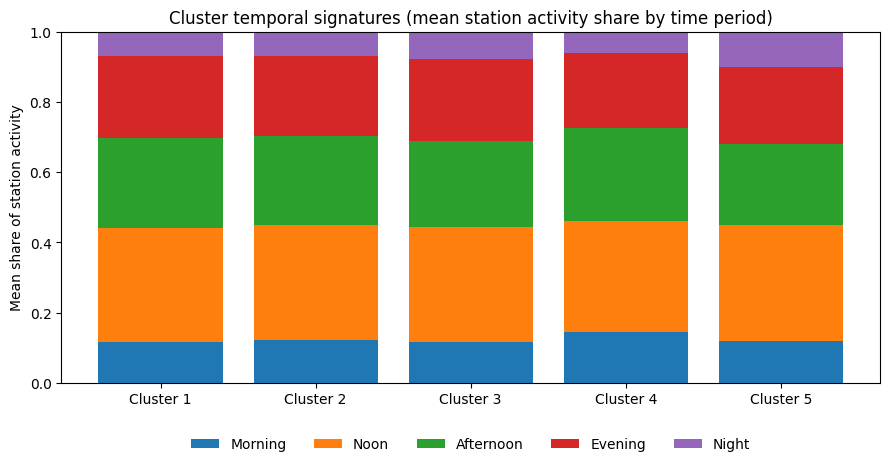

In [ ]:
cluster_shares = (
    df.groupby("cluster")[[f"share_{p}" for p in periods]]
      .mean()
      .sort_index()
)

fig, ax = plt.subplots(figsize=(9, 4.8))
bottom = np.zeros(len(cluster_shares))
x = np.arange(len(cluster_shares.index))

for p in periods:
    vals = cluster_shares[f"share_{p}"].values
    ax.bar(x, vals, bottom=bottom, label=p.capitalize())
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels([f"Cluster {c}" for c in cluster_shares.index])
ax.set_ylabel("Mean share of station activity")
ax.set_title("Cluster temporal signatures (mean station activity share by time period)")
ax.legend(ncol=5, bbox_to_anchor=(0.5, -0.12), loc="upper center", frameon=False)
ax.set_ylim(0, 1)

plt.tight_layout()
#plt.savefig(out_path, dpi=200)
plt.show()

#### Selected columns...

In [ ]:
flow_cols = ['closeness', 'betweenness',
             'closeness_norm', 'betweenness_norm',
             'trips_origins', 'trips_destinations', 'trips_inflow', 'trips_outflow', 'trips_node_flow', 'trips_through_flow',
             'morning_trips_origins', 'morning_trips_destinations',
             'morning_trips_inflow', 'morning_trips_outflow',
             'morning_trips_node_flow', 'morning_trips_through_flow',
             'afternoon_trips_origins', 'afternoon_trips_destinations',
             'afternoon_trips_inflow', 'afternoon_trips_outflow',
             'afternoon_trips_node_flow', 'afternoon_trips_through_flow']

station_flow_metrics_w_types = station_flow_metrics_w_types_all[['name', 'k_5'] + flow_cols]

station_flow_metrics_w_types.to_csv("../results_flow_metrics.csv", index=False)

In [169]:
cluster_means = all_flow_metrics2.groupby('k_5')[flow_cols].mean()
cluster_means.reset_index()

,k_5,closeness,betweenness,closeness_norm,betweenness_norm,morning_trips_origins,morning_trips_destinations,morning_trips_inflow,morning_trips_outflow,morning_trips_node_flow,morning_trips_through_flow,afternoon_trips_origins,afternoon_trips_destinations,afternoon_trips_inflow,afternoon_trips_outflow,afternoon_trips_node_flow,afternoon_trips_through_flow
0,1,0.000217,0.296419,1.380804,2.126256,18026.000000,33435.000000,151678.666667,136269.666667,287948.333333,236487.333333,70069.833333,59309.666667,302127.666667,312887.833333,615015.500000,485636.000000
1,2,0.000168,0.141085,1.068217,1.012024,12278.800000,10740.100000,77276.100000,78814.800000,156090.900000,133072.000000,24887.600000,27145.800000,162728.100000,160469.900000,323198.000000,271164.600000
2,3,0.000153,0.115541,0.976317,0.828790,15491.555556,7968.555556,52996.000000,60519.000000,113515.000000,90054.888889,22572.555556,27705.444444,119339.333333,114206.444444,233545.777778,183267.777778
3,4,0.000150,0.142488,0.953879,1.022086,9931.888889,12458.555556,64860.555556,62333.888889,127194.444444,104804.000000,23738.111111,21583.777778,123487.333333,125641.666667,249129.000000,203807.111111
4,5,0.000120,0.062237,0.766124,0.446434,10448.100000,7238.100000,38717.300000,41927.300000,80644.600000,62958.400000,16250.800000,17768.000000,76909.000000,75391.800000,152300.800000,118282.000000


In [173]:
df_table_example.T.reset_index()

,index,0,1,2,3,4
0,k_5,1.000000,2.000000,3.000000,4.000000,5.000000
1,closeness,0.000217,0.000168,0.000153,0.000150,0.000120
2,betweenness,0.296419,0.141085,0.115541,0.142488,0.062237
3,closeness_norm,1.380804,1.068217,0.976317,0.953879,0.766124
4,betweenness_norm,2.126256,1.012024,0.828790,1.022086,0.446434
5,morning_trips_origins,18026.000000,12278.800000,15491.555556,9931.888889,10448.100000
6,morning_trips_destinations,33435.000000,10740.100000,7968.555556,12458.555556,7238.100000
7,morning_trips_inflow,151678.666667,77276.100000,52996.000000,64860.555556,38717.300000
8,morning_trips_outflow,136269.666667,78814.800000,60519.000000,62333.888889,41927.300000
9,morning_trips_node_flow,287948.333333,156090.900000,113515.000000,127194.444444,80644.600000


In [177]:
cluster_means.T.reset_index()

k_5,index,1,2,3,4,5
0,closeness,0.000217,0.000168,0.000153,0.000150,0.000120
1,betweenness,0.296419,0.141085,0.115541,0.142488,0.062237
2,closeness_norm,1.380804,1.068217,0.976317,0.953879,0.766124
3,betweenness_norm,2.126256,1.012024,0.828790,1.022086,0.446434
4,morning_trips_origins,18026.000000,12278.800000,15491.555556,9931.888889,10448.100000
5,morning_trips_destinations,33435.000000,10740.100000,7968.555556,12458.555556,7238.100000
6,morning_trips_inflow,151678.666667,77276.100000,52996.000000,64860.555556,38717.300000
7,morning_trips_outflow,136269.666667,78814.800000,60519.000000,62333.888889,41927.300000
8,morning_trips_node_flow,287948.333333,156090.900000,113515.000000,127194.444444,80644.600000
9,morning_trips_through_flow,236487.333333,133072.000000,90054.888889,104804.000000,62958.400000


In [178]:
# print latex table example 
df_table_example = cluster_means.T.reset_index()
print(df_table_example.to_latex(index=False,
                  formatters={"name": str.upper},
                  float_format="{:.2f}".format,
))  

\begin{tabular}{lrrrrr}
\toprule
index & 1 & 2 & 3 & 4 & 5 \\
\midrule
closeness & 0.00 & 0.00 & 0.00 & 0.00 & 0.00 \\
betweenness & 0.30 & 0.14 & 0.12 & 0.14 & 0.06 \\
closeness_norm & 1.38 & 1.07 & 0.98 & 0.95 & 0.77 \\
betweenness_norm & 2.13 & 1.01 & 0.83 & 1.02 & 0.45 \\
morning_trips_origins & 18026.00 & 12278.80 & 15491.56 & 9931.89 & 10448.10 \\
morning_trips_destinations & 33435.00 & 10740.10 & 7968.56 & 12458.56 & 7238.10 \\
morning_trips_inflow & 151678.67 & 77276.10 & 52996.00 & 64860.56 & 38717.30 \\
morning_trips_outflow & 136269.67 & 78814.80 & 60519.00 & 62333.89 & 41927.30 \\
morning_trips_node_flow & 287948.33 & 156090.90 & 113515.00 & 127194.44 & 80644.60 \\
morning_trips_through_flow & 236487.33 & 133072.00 & 90054.89 & 104804.00 & 62958.40 \\
afternoon_trips_origins & 70069.83 & 24887.60 & 22572.56 & 23738.11 & 16250.80 \\
afternoon_trips_destinations & 59309.67 & 27145.80 & 27705.44 & 21583.78 & 17768.00 \\
afternoon_trips_inflow & 302127.67 & 162728.10 & 119339.3

In [179]:
cluster_means_save = cluster_means.reset_index()
cluster_means_save.to_csv("../results/network_metrics.csv", index=False)

### Correlation

In [ ]:
base_cols = ['closeness', 'betweenness']
flow_cols = []
base_corr_cols = ['']

In [ ]:
flow_corr_cols = ['JOBS_POP15', 'B_TOTAL', 'B_RES', 'POP']

In [ ]:
flow_cols = [i for i in all_flow_metrics.columns[1:]]
social_cols = [i for i in social.columns[1:]]
flow_neighatt = all_flow_metrics.merge(all,
                                       left_on='station',
                                       right_on='name',
                                       how='left')

flow_neighatt.head()

In [35]:
all.columns

Index(['name', 'B_COMSERV', 'B_INDU', 'B_PUBINST', 'B_RES', 'B_TOTAL', 'GREEN',
       'WATER', 'U_REC', 'U_PROD', 'U_RESI', 'C_BUILD', 'C_HYDRO', 'C_NAT',
       'C_TECH', 'ACLI_S', 'COSP_S', 'PEDU_S', 'FOOD_S', 'HEWE_S', 'MOBI_S',
       'NILI_S', 'ACLI_POP', 'COSP_POP', 'PEDU_POP', 'FOOD_POP', 'HEWE_POP',
       'MOBI_POP', 'NILI_POP', 'POI_TOTAL', 'JOBS', 'JOBS_POP15', 'JAG_S',
       'JMA_S', 'JCO_S', 'JCOR_S', 'JCOM_S', 'JENT_S', 'JTRA_S', 'JLSE_S',
       'JPSE_S', 'JEDU_S', 'STU', 'STUU15_S', 'STUO16_S', 'STUO16_POP15',
       'STUU15_CHILD', 'STU_POP', 'STUO16_OSTU', 'POP', 'POP15_S', 'CHILD14_S',
       'CHILD7_S', 'INCLOW_S', 'INCLOWMID_S', 'INCMID_S', 'INCUPMID_S',
       'INCHIGH_S', 'OSAL_S', 'OSKIL_S', 'OUSKIL_S', 'ORET_S', 'OSTU_S',
       'ONOP_S', 'HOUSEH1', 'HOUSEH2', 'HOUSEH3', 'CARS', 'CDEN'],
      dtype='object')

In [ ]:
corr = flow_neighatt[flow_cols + social_cols].corr()

# keep only flow vs neighborhood block
corr_flow_neigh = corr.loc[flow_cols, social_cols]
corr_flow_neigh

,POP,POP15,CHILD14,CHILD7,INCLOW,INCLOWMID,INCMID,INCUPMID,INCHIGH,OSAL,...,OUSKIL,ORET,OSTU,OEMP,ONOP,HOUSEH1,HOUSEH2,HOUSEH3,CARS,CDEN2
origins,0.032467,0.364618,-0.250463,-0.272038,-0.059234,-0.008774,0.019538,-0.008959,0.098183,0.340511,...,-0.415952,-0.262137,-0.034790,0.380455,-0.214088,-0.151348,0.414108,-0.090566,0.024556,-0.039577
destinations,0.018081,0.369408,-0.249188,-0.278587,-0.071879,-0.014664,0.026759,0.000778,0.109447,0.343640,...,-0.420937,-0.245781,-0.053977,0.381331,-0.216184,-0.172968,0.436325,-0.077168,0.014539,-0.018602
inflow,0.060119,0.511184,-0.260615,-0.440382,-0.287899,-0.175164,0.249003,0.166918,0.279931,0.464372,...,-0.546213,-0.214136,-0.120025,0.429854,-0.423283,-0.025939,0.476550,-0.327015,0.113993,-0.035101
outflow,0.063229,0.512250,-0.261493,-0.441082,-0.287442,-0.175405,0.249527,0.166446,0.279442,0.465523,...,-0.547219,-0.217507,-0.117054,0.430918,-0.425064,-0.021008,0.473624,-0.331781,0.116742,-0.039250
node_flow,0.061669,0.511727,-0.261059,-0.440742,-0.287679,-0.175289,0.249270,0.166687,0.279695,0.464957,...,-0.546728,-0.215820,-0.118549,0.430395,-0.424180,-0.023484,0.475105,-0.329396,0.115365,-0.037168
through_flow,0.063777,0.495192,-0.239173,-0.435265,-0.308630,-0.194126,0.274667,0.187868,0.291450,0.448085,...,-0.523401,-0.187556,-0.123425,0.400968,-0.429631,0.008552,0.441563,-0.351541,0.125242,-0.035480
closeness,0.230560,0.638930,-0.457919,-0.464301,-0.350248,-0.377111,0.387914,0.305152,0.443014,0.692716,...,-0.757536,-0.484345,0.091512,0.433204,-0.563820,0.174731,0.360078,-0.507094,0.239070,-0.310148
betweenness,0.038875,0.529008,-0.382281,-0.382374,-0.352075,-0.302471,0.336846,0.289883,0.382223,0.458513,...,-0.541564,-0.309113,-0.052528,0.521034,-0.432530,0.046745,0.367850,-0.352084,0.079144,-0.150251


In [ ]:
corr_flow_neigh = (
    flow_neighatt[flow_cols + social_cols]
    .corr(method="spearman")
    .loc[flow_cols, social_cols]
)

corr_flow_neigh

,POP,POP15,CHILD14,CHILD7,INCLOW,INCLOWMID,INCMID,INCUPMID,INCHIGH,OSAL,...,OUSKIL,ORET,OSTU,OEMP,ONOP,HOUSEH1,HOUSEH2,HOUSEH3,CARS,CDEN2
origins,0.222692,0.364764,-0.262579,-0.277942,0.021564,0.020155,-0.029316,-0.005356,0.057928,0.412685,...,-0.425793,-0.381254,0.081748,0.161804,-0.286399,-0.133416,0.307274,-0.179868,0.259056,-0.041156
destinations,0.235236,0.377731,-0.271318,-0.288372,0.021424,0.013953,-0.025511,-0.004087,0.058210,0.423679,...,-0.439746,-0.385060,0.098661,0.178858,-0.285130,-0.154857,0.319202,-0.173465,0.265962,-0.038055
inflow,0.144891,0.417759,-0.152361,-0.427625,-0.337562,-0.163214,0.286258,0.189993,0.278083,0.514729,...,-0.494292,-0.225229,-0.036786,0.170965,-0.521494,-0.044472,0.500831,-0.489633,0.189429,0.069063
outflow,0.145314,0.412544,-0.147851,-0.424524,-0.337703,-0.155743,0.284426,0.186610,0.273714,0.512333,...,-0.489077,-0.221846,-0.042424,0.171106,-0.518534,-0.040718,0.499399,-0.489781,0.191121,0.067371
node_flow,0.150106,0.410994,-0.149683,-0.421001,-0.336152,-0.158280,0.283862,0.188020,0.276533,0.516561,...,-0.494715,-0.228048,-0.037773,0.170120,-0.519662,-0.040501,0.499399,-0.489633,0.194785,0.063848
through_flow,0.110296,0.415656,-0.138364,-0.438646,-0.365868,-0.187588,0.319041,0.218759,0.294640,0.464457,...,-0.450917,-0.170240,-0.042313,0.172073,-0.510014,-0.045153,0.490202,-0.493293,0.153456,0.079972
closeness,0.311769,0.557717,-0.351938,-0.383510,-0.368428,-0.346300,0.331501,0.327696,0.451445,0.674982,...,-0.727273,-0.375617,0.176462,0.253418,-0.581254,-0.024402,0.382025,-0.481832,0.299225,-0.176180
betweenness,0.105598,0.460605,-0.355078,-0.308530,-0.448244,-0.321456,0.413633,0.333746,0.394633,0.473107,...,-0.507506,-0.330850,0.128766,0.364401,-0.475791,-0.062664,0.347195,-0.403937,0.079322,-0.111814


In [68]:
strong = (
    corr_flow_neigh
    .abs()
    .stack()
    .sort_values(ascending=False)
)

strong[strong > 0.5]


closeness     OUSKIL     0.727273
              OSAL       0.674982
              ONOP       0.581254
              POP15      0.557717
inflow        ONOP       0.521494
node_flow     ONOP       0.519662
outflow       ONOP       0.518534
node_flow     OSAL       0.516561
inflow        OSAL       0.514729
outflow       OSAL       0.512333
through_flow  ONOP       0.510014
betweenness   OUSKIL     0.507506
inflow        HOUSEH2    0.500831
dtype: float64

In [75]:
for i in strong:
    print(strong)

closeness     OUSKIL       0.727273
              OSAL         0.674982
              ONOP         0.581254
              POP15        0.557717
inflow        ONOP         0.521494
                             ...   
destinations  INCLOW       0.021424
origins       INCLOWMID    0.020155
destinations  INCLOWMID    0.013953
origins       INCUPMID     0.005356
destinations  INCUPMID     0.004087
Length: 168, dtype: float64
closeness     OUSKIL       0.727273
              OSAL         0.674982
              ONOP         0.581254
              POP15        0.557717
inflow        ONOP         0.521494
                             ...   
destinations  INCLOW       0.021424
origins       INCLOWMID    0.020155
destinations  INCLOWMID    0.013953
origins       INCUPMID     0.005356
destinations  INCUPMID     0.004087
Length: 168, dtype: float64
closeness     OUSKIL       0.727273
              OSAL         0.674982
              ONOP         0.581254
              POP15        0.557717
inflow  

In [84]:
corr_long = (
    corr_flow_neigh
    .reset_index()
    .melt(id_vars="index",
          var_name="neighborhood_var",
          value_name="correlation")
    .rename(columns={"index": "flow_var"})
)
corr_long.sort_values(by="correlation").head(20)

,flow_var,neighborhood_var,correlation
94,closeness,OUSKIL,-0.727273
126,closeness,ONOP,-0.581254
122,inflow,ONOP,-0.521494
124,node_flow,ONOP,-0.519662
123,outflow,ONOP,-0.518534
125,through_flow,ONOP,-0.510014
95,betweenness,OUSKIL,-0.507506
92,node_flow,OUSKIL,-0.494715
90,inflow,OUSKIL,-0.494292
149,through_flow,HOUSEH3,-0.493293


<Axes: xlabel='through_flow', ylabel='HOUSEH3'>

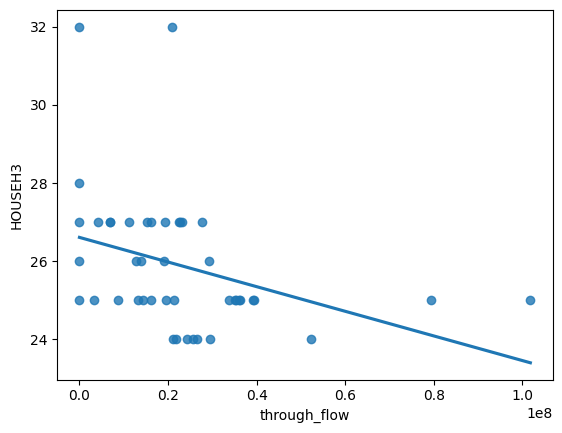

In [ ]:
sns.regplot(data=flow_neighatt, x="through_flow", y="HOUSEH3", ci=None)
#sns.regplot(data=test2, x="closeness", y="ONOP", ci=None)

# Notes
Using shortest path assignment flows to compute in-degree/out-degree does NOT give actual arrival/departure volumes.

To compute:
“Where do people come from?” -> Use origin_flow.
“Where do people go?” ->Use destination_flow.

To compute:
“Which stations are important because many people pass through?” -> Use through_flow.

To compute:
“Which edges carry the most passenger load?” -> Use link_flow.

To compute:
“Which stations are structurally important in the network regardless of flows?” -> Use graph centrality (betweenness, closeness) on distance, not flows.

# Archived

In [ ]:
test = metrics_df.reset_index(names=['station'])
test # merge with neighborhood types
#test.groupby('k_5').sum()

In [ ]:
def station_flow_metrics(DiG,
                         BaG, 
                         od_df, 
                         trips_col="trips", 
                         flow_col="flow",
                         station_names=None):
    metrics_df = pd.DataFrame()

    # 1. start and end nodes
    origins = od_df.groupby("from")[trips_col].sum().reindex(DG.nodes(), fill_value=0)
    destinations = od_df.groupby("to")[trips_col].sum().reindex(DG.nodes(), fill_value=0)
    metrics_df['origins'] = origins
    metrics_df['destinations'] = destinations

    # 2. node inflow and outflow
    inflow = DiG.in_degree(weight=flow_col)     # People arriving at or through station
    outflow = DiG.out_degree(weight=flow_col)   # People departing at or through station
    inflow_values = {node: inflow[node] for node in DiG.nodes()}
    outflow_values = {node: outflow[node] for node in DiG.nodes()}
    metrics_df['inflow'] = inflow_values
    metrics_df['outflow'] = outflow_values

    # 3. node through-flow
    node_flow = {node: 0 for node in DG.nodes()}
    for u, v, data in DG.edges(data=True):
        node_flow[u] += data[flow_col]
        node_flow[v] += data[flow_col]
    metrics_df['node_flow'] = node_flow

    # 3. Transfer Flow
    through_flow = {}
    for n in DiG.nodes():
        through_flow[n] = inflow[n] + outflow[n] - origins[n] - destinations[n]
    metrics_df['through_flow'] = through_flow


    # 4. Structural centralities
    closeness = nx.closeness_centrality(BaG, distance="distance")
    betweenness = nx.betweenness_centrality(BaG, weight="distance")
    metrics_df['closeness'] = closeness
    metrics_df['betweenness'] = betweenness

    metrics_df = metrics_df.reset_index(names=['station'])
    return metrics_df

In [ ]:
morning_flow_metrics = station_flow_metrics(DG, BG, 
                                            od_all,
                                            trips_col="morning_peak_trips",
                                            flow_col="flow_morning")
morning_flow_metrics

In [ ]:
test = station_flow_metrics(DG, BG, od_total)
flow_cols = [i for i in test.columns[1:]]
social_cols = [i for i in social.columns[1:]]
test2 = test.merge(all,
                   left_on='station',
                   right_on='name',
                   how='left')

test2.head()